# Stability of wearing-position bias with sample size

Johannes Zauner

## Preface

The metric comparison established that wearing position (chest and wrist, relative to the glasses reference) introduces an outcome-level *bias* in light exposure metrics. This document asks a complementary, design-oriented question:

> **If and when does the estimated bias stabilise as data accumulate?**

We probe this along two independent axes with bootstrapping:

1.  **Participants** — how the sampling standard deviation (SD) of the mean bias shrinks as the number of participants grows (1–200, resampled with replacement).
2.  **Participant-days** — how it shrinks as the number of days *per participant* grows (1–7), holding the full participant set.

At each sample size we record the SD across bootstrap replicates of the mean bias — a bootstrap standard error of the average wearing-position bias. Because the six chosen metrics have very different units, each SD curve is normalised to its value at the smallest sample, so all traces start at 1 and the *shape* of stabilisation is directly comparable across metrics.

The analysis uses one metric per metric category:

| Category (metric family/type) | Metric                        |
|-------------------------------|-------------------------------|
| Duration above threshold      | Duration above 250 lx mel EDI |
| Dose                          | Melanopic dose                |
| Mean level                    | Mean mel EDI                  |
| Spectral                      | MDER                          |
| Pulses                        | N pulses above 250 lx mel EDI |
| Timing                        | Brightest 10 h midpoint       |

## Setup

Packages for data wrangling (`tidyverse`), figure assembly (`patchwork`, `cowplot`), the wearing-position color palette (`ggsci`), and project paths (`here`).

In [ ]:
#| label: setup
#| warning: false
#| message: false
#| filename: Setup
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Attaching package: 'cowplot'

The following object is masked from 'package:patchwork':

    align_plots

The following object is masked from 'package:lubridate':

    stamp

here() starts at /Users/zauner/Documents/Arbeit/12-TUM/Repos_Misc/WearingPositionError_2026

The pre-processed metrics are loaded from the `.RData` file produced by the preparation notebook. The object `metrics` is long-format with one row per participant (`Id`), date (`Date`), wearing `position`, and `metric`.

In [ ]:
#| label: import-metrics
#| filename: Import metrics
load(here("data/prepared_metrics.RData"))

A single seed is set for the whole notebook so every bootstrap is reproducible.

In [ ]:
#| label: set-seed
#| filename: Set seed
set.seed(7391)

## Metric selection

We select one metric per category and confirm that each string is actually present in the data (the metric names come from `LightLogR` and are easy to mistype). The pulses metric is stored as `n_pulses_above_250`.

In [ ]:
#| label: select-metrics
#| filename: Define and verify target metrics
target_metrics <- c(
  "duration_above_250",      # Duration above 250 lx mel EDI
  "dose",                    # Melanopic dose
  "mean_MEDI",               # Mean mel EDI
  "MDER",                    # MDER
  "n_pulses_above_250",      # N pulses above 250 lx mel EDI
  "brightest_10h_midpoint"   # Brightest 10 h midpoint
)

missing <- setdiff(target_metrics, unique(metrics$metric))
stopifnot("Some target metrics are absent from `metrics`" = length(missing) == 0)

metric_labels <- c(
  duration_above_250     = "Duration > 250 lx",
  dose                   = "Melanopic dose",
  mean_MEDI              = "Mean mel EDI",
  MDER                   = "MDER",
  n_pulses_above_250     = "N pulses > 250 lx",
  brightest_10h_midpoint = "Brightest 10h midpoint"
)

A shared, named palette assigns one color per wearing position, matching the comparison notebook (`ggsci::pal_jco()`).

In [ ]:
#| label: position-colors
#| filename: Wearing-position palette
position_colors <- ggsci::pal_jco()(3) |> set_names(c("glasses", "chest", "wrist"))

## Defining the bias

For each metric we align the three positions on the same participant-day and compute the bias of each comparison position (chest, wrist) against the glasses reference:

$$\text{bias} = \text{value}_{\text{position}} - \text{value}_{\text{glasses}}$$

Bias is computed on each metric’s *stored* scale. Note that `mean_MEDI` is already stored on a log scale (mean of log-transformed melanopic EDI), while the others are on their native units; the later normalisation makes the SD curves comparable regardless.

In [ ]:
#| label: bias-table-manual
#| filename: Build the bias table (illustrative, single metric)
metrics |>
  filter(metric == "dose",
         position %in% c("glasses", "chest", "wrist")) |>
  select(metric, site, Id, Date, position, value) |>
  pivot_wider(names_from = position, values_from = value) |>
  mutate(bias_chest = chest - glasses,
         bias_wrist = wrist - glasses) |>
  head()

# A tibble: 6 × 9
  metric site  Id        Date         chest glasses  wrist bias_chest bias_wrist
  <chr>  <chr> <chr>     <date>       <dbl>   <dbl>  <dbl>      <dbl>      <dbl>
1 dose   BAUA  BAUA_S001 2025-06-11 41810.   43150. 4.31e4     -1339.      -90.3
2 dose   BAUA  BAUA_S001 2025-06-12  7687.    6964. 1.40e4       722.     6999. 
3 dose   BAUA  BAUA_S001 2025-06-13 42925.    9594. 5.97e4     33330.    50062. 
4 dose   BAUA  BAUA_S001 2025-06-14 19366.    9383. 3.68e4      9983.    27384. 
5 dose   BAUA  BAUA_S001 2025-06-15    16.9   1517. 6.57e0     -1500.    -1511. 
6 dose   BAUA  BAUA_S001 2025-06-16 11423.   10870. 1.10e4       554.       83.2

## Testing the approach

Before generalising, we validate the full pipeline on a **single metric (`dose`)** with a **small number of bootstraps (B = 20)**. This keeps the logic transparent and confirms the end-to-end path (bias → bootstrap → SD curve) behaves sensibly before committing to the expensive full run.

First, the bias table for the test metric, in long form (one row per participant-day and comparison position):

In [ ]:
#| label: test-bias
#| filename: Test bias table (single metric)
test_bias <-
  metrics |>
  filter(metric == "dose",
         position %in% c("glasses", "chest", "wrist")) |>
  select(metric, site, Id, Date, position, value) |>
  pivot_wider(names_from = position, values_from = value) |>
  pivot_longer(c(chest, wrist), names_to = "position", values_to = "value_pos") |>
  mutate(bias = value_pos - glasses) |>
  filter(!is.na(bias)) |>
  select(metric, position, site, Id, Date, bias)

**Participant axis (test).** For a handful of sample sizes, we collapse each participant to their mean bias, resample participants with replacement, and take the SD of the resampled mean across B = 20 replicates.

In [ ]:
#| label: test-participants
#| filename: Test participant bootstrap
test_A <-
  test_bias |>
  group_by(metric, position) |>
  group_modify(\(d, key) {
    per_id <- d |> group_by(Id) |> summarise(mb = mean(bias), .groups = "drop") |> pull(mb)
    map_dfr(c(1, 5, 25, 100, 200), \(n) {
      est <- replicate(20, mean(sample(per_id, n, replace = TRUE)))
      tibble(n = n, sd = sd(est))
    })
  }) |>
  ungroup()

test_A

# A tibble: 10 × 4
   metric position     n    sd
   <chr>  <chr>    <dbl> <dbl>
 1 dose   chest        1 6517.
 2 dose   chest        5 1754.
 3 dose   chest       25 2279.
 4 dose   chest      100  818.
 5 dose   chest      200  472.
 6 dose   wrist        1 8071.
 7 dose   wrist        5 3767.
 8 dose   wrist       25 1127.
 9 dose   wrist      100  604.
10 dose   wrist      200  371.

**Participant-day axis (test).** For each participant we resample `n_days` of their days with replacement, average, then average across participants; the SD across B = 20 replicates is recorded for 1–7 days.

In [ ]:
#| label: test-days
#| filename: Test participant-day bootstrap
test_B <-
  test_bias |>
  group_by(metric, position) |>
  group_modify(\(d, key) {
    by_id <- split(d$bias, d$Id)
    map_dfr(1:7, \(nd) {
      est <- replicate(20, {
        per_id <- map_dbl(by_id, \(v) mean(sample(v, nd, replace = TRUE)))
        mean(per_id)
      })
      tibble(n = nd, sd = sd(est))
    })
  }) |>
  ungroup()

test_B

# A tibble: 14 × 4
   metric position     n    sd
   <chr>  <chr>    <int> <dbl>
 1 dose   chest        1  885.
 2 dose   chest        2  589.
 3 dose   chest        3  622.
 4 dose   chest        4  447.
 5 dose   chest        5  515.
 6 dose   chest        6  427.
 7 dose   chest        7  345.
 8 dose   wrist        1 1065.
 9 dose   wrist        2  611.
10 dose   wrist        3  619.
11 dose   wrist        4  381.
12 dose   wrist        5  467.
13 dose   wrist        6  516.
14 dose   wrist        7  396.

Both curves decrease with sample size, as expected — the participant axis roughly follows a $1/\sqrt{N}$ shape, and additional days per participant reduce the SD toward a between-participant floor. The approach is sound.

## Generalising into reusable functions

The test logic is repeated identically across all six metrics and both positions, so it is factored into `scripts/bootstrap_stability.R`. Sourcing it exposes five functions:

- **`compute_bias()`** — builds the long bias table (comparison − reference) per participant-day for any set of metrics.
- **`boot_participants()`** — the participant axis: collapses each participant to their mean bias and resamples participants with replacement.
- **`boot_days()`** — the participant-day axis: resamples `n_days` per participant and averages across the full participant set.
- **`bootstrap_stability()`** — runs both axes and adds `sd_norm`, each SD curve normalised to its smallest-sample value.
- **`color_strips_grid()`** — tints the facet strips of the final figure by wearing position.

In [ ]:
#| label: source-functions
#| filename: Source bootstrap-stability helpers
source(here("scripts/bootstrap_stability.R"))

The bias table for all six metrics and both comparison positions:

In [ ]:
#| label: bias-all
#| filename: Bias table for all target metrics
bias_df <- compute_bias(metrics, target_metrics)
bias_df |> count(metric, position)

# A tibble: 12 × 3
   metric                 position     n
   <chr>                  <chr>    <int>
 1 MDER                   chest      602
 2 MDER                   wrist      602
 3 brightest_10h_midpoint chest      604
 4 brightest_10h_midpoint wrist      604
 5 dose                   chest      604
 6 dose                   wrist      604
 7 duration_above_250     chest      604
 8 duration_above_250     wrist      604
 9 mean_MEDI              chest      604
10 mean_MEDI              wrist      604
11 n_pulses_above_250     chest      604
12 n_pulses_above_250     wrist      604

## Full bootstrap run

We now run both axes for every metric and position with **B = 1000** replicates, across participants 1–200 and participant-days 1–7. The chunk is cached because the full run is the expensive step; re-renders reuse the stored result.

In [ ]:
#| label: full-run
#| filename: Full bootstrap run
#| cache: true
stability <- bootstrap_stability(
  bias_df,
  n_range   = 1:200,
  day_range = 1:7,
  B         = 1000
)

## Stabilisation figure

The four panels cross the two comparison positions (rows, strip color = position) with the two bootstrap axes (columns). Each line is one metric; the y-axis is the bias SD normalised to the smallest sample, so all traces begin at 1. The x-axes are free, so the participant column spans 1–200 while the participant-day column spans 1–7.

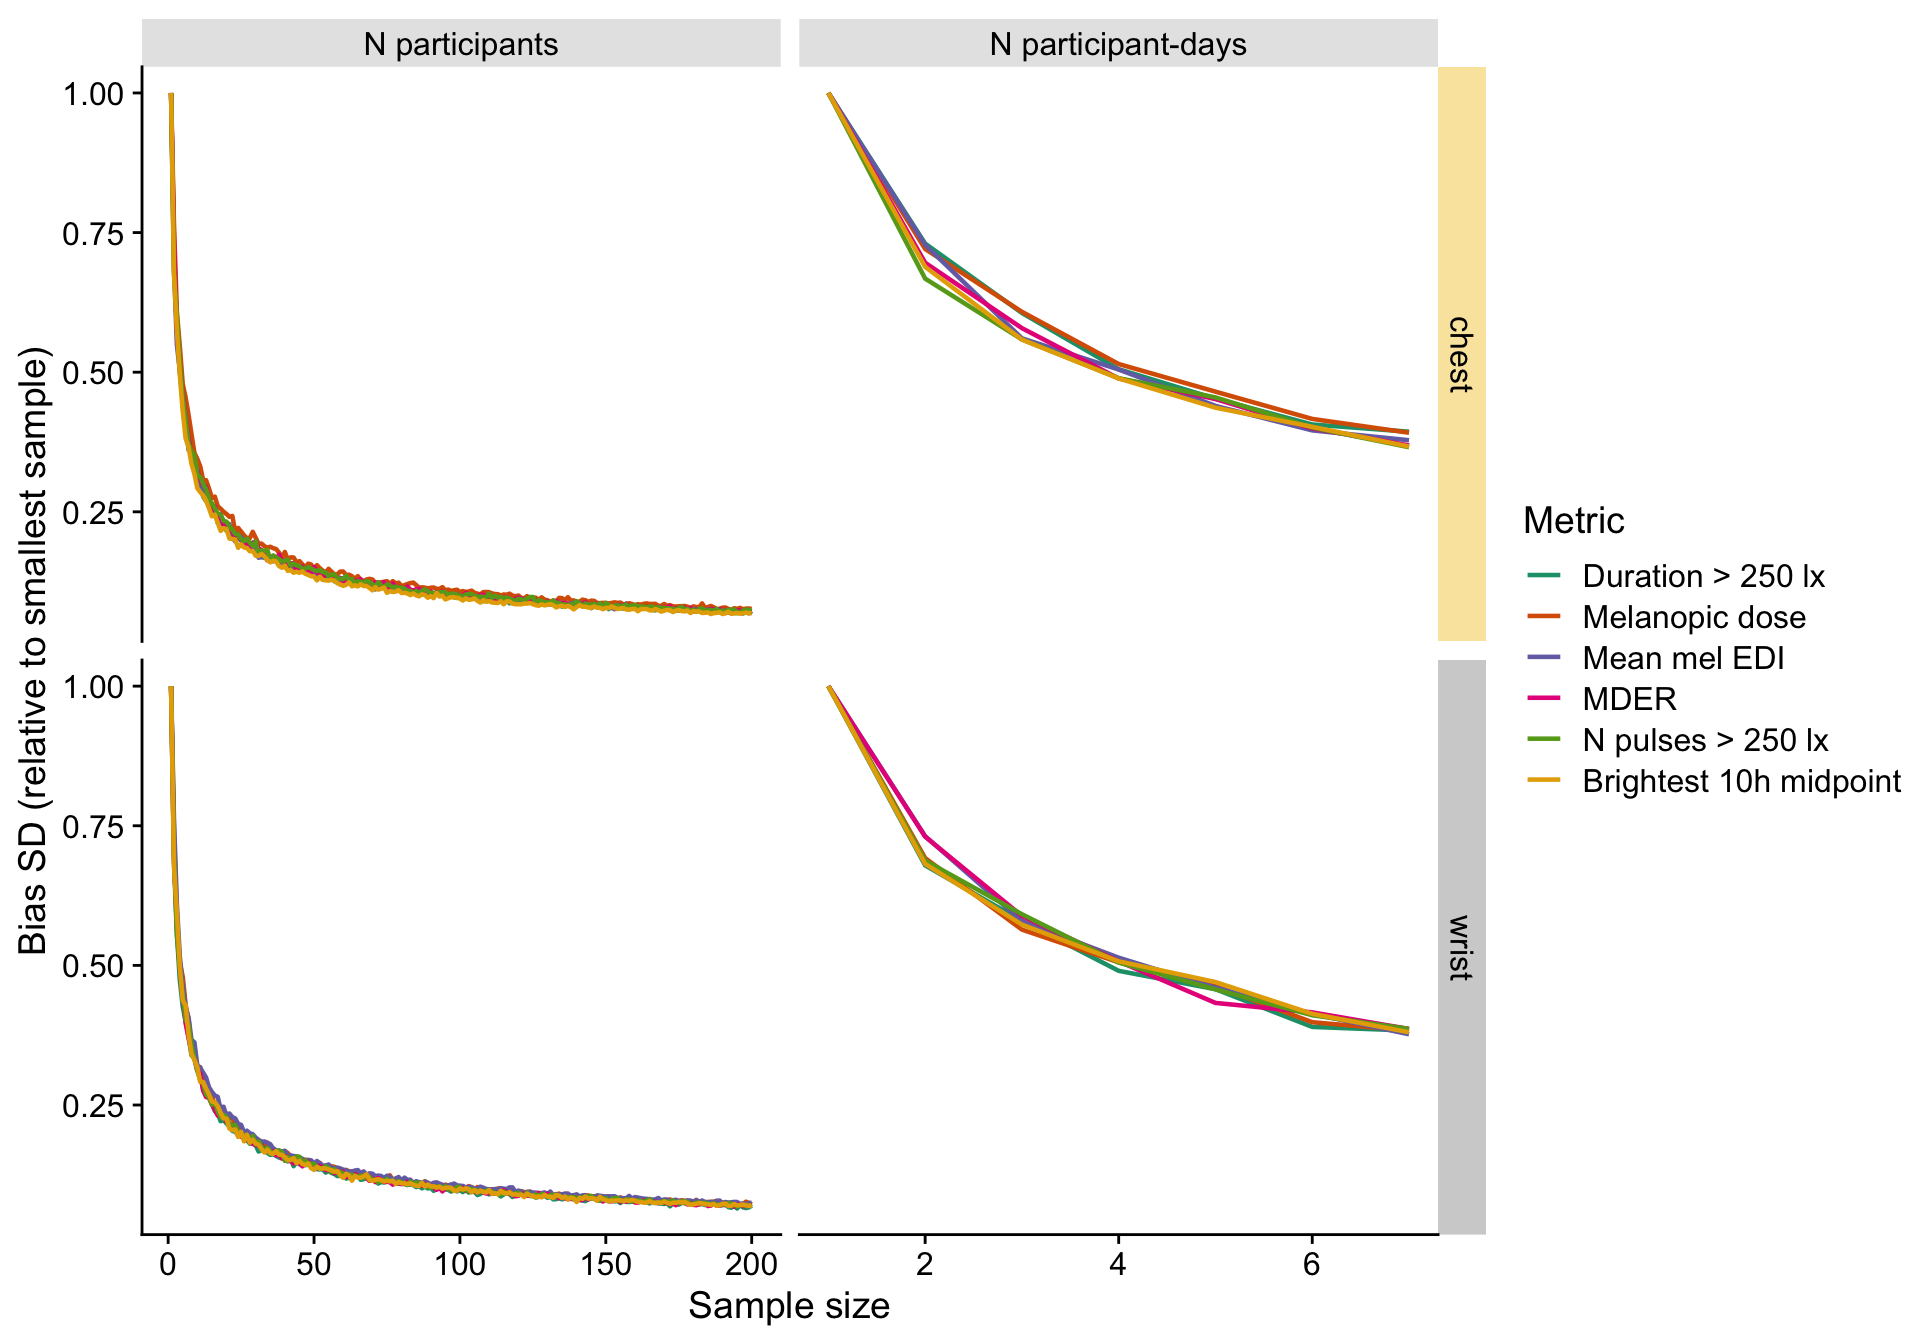

In [ ]:
#| label: fig-stability
#| filename: Four-panel stability figure
#| fig-width: 10
#| fig-height: 7
#| warning: false
stability_plot <-
  stability |>
  mutate(
    metric = factor(metric, levels = names(metric_labels), labels = metric_labels),
    boot_type = factor(boot_type,
                       levels = c("participants", "participant-days"),
                       labels = c("N participants", "N participant-days"))
  ) |>
  ggplot(aes(n, sd_norm, colour = metric)) +
  geom_line(linewidth = 0.8) +
  facet_grid(position ~ boot_type, scales = "free_x") +
  scale_colour_brewer(palette = "Dark2", name = "Metric") +
  labs(x = "Sample size",
       y = "Bias SD (relative to smallest sample)") +
  theme_cowplot() +
  theme(strip.background = element_rect(fill = "grey90"))

fig_stability <- ggdraw(color_strips_grid(stability_plot, position_colors))
fig_stability

In [ ]:
#| label: save-figure
#| filename: Save the stability figure
ggsave(here("output/figures/Fig_bias_stability.pdf"), fig_stability,
       width = 10, height = 7, device = cairo_pdf)
ggsave(here("output/figures/Fig_bias_stability.jpeg"), fig_stability,
       width = 10, height = 7)

## Interpretation

The participant axis dominates stabilisation: the normalised bias SD falls steeply over the first few dozen participants and then flattens, consistent with a $1/\sqrt{N}$ standard error. The participant-day axis yields a more modest reduction — moving from one to several days per participant lowers the SD toward a between-participant floor that additional days cannot cross, because the residual variability is dominated by differences *between* people rather than *within* them.

Read together, the panels suggest that for these metrics precision in the estimated wearing-position bias is bought far more cheaply by recruiting more participants than by extending the wear duration of those already enrolled. The exact plateau point can be read off each panel per metric; the normalisation means the y-axis reflects relative stabilisation shape, not absolute bias magnitude.

## Session info

In [ ]:
#| label: session-info
sessionInfo()

R version 4.5.0 (2025-04-11)
Platform: aarch64-apple-darwin20
Running under: macOS 26.5.2

Matrix products: default
BLAS:   /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.0.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.1

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

time zone: Europe/Berlin
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices datasets  utils     methods   base     

other attached packages:
 [1] here_1.0.2      cowplot_1.2.0   patchwork_1.3.2 lubridate_1.9.5
 [5] forcats_1.0.1   stringr_1.6.0   dplyr_1.2.1     purrr_1.2.2    
 [9] readr_2.2.0     tidyr_1.3.2     tibble_3.3.1    ggplot2_4.0.2  
[13] tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] utf8_1.2.6         generics_0.1.4     renv_1.1.4         stringi_1.8.7     
 [5] hms_1.1.4          digest_0.6.39      magrittr_2.0.5     evaluate_1.0.5